In [1]:
# Copyright 2025 Google LLC

# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at

# https://www.apache.org/licenses/LICENSE-2.0

# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

In [2]:
!pip install --upgrade https://github.com/google-deepmind/nuclease-design.git
# SETUP

In [3]:
from os import path

import pandas as pd
import seaborn as sns
import tensorflow as tf

from zero_shot_sampling import alignment
from zero_shot_sampling import msa_vae
from zero_shot_sampling import vae
from nuclease_design import constants as nuclease_constants

# SETUP

In [4]:
VAE_TRAINING_CONFIG = vae.VAETrainingConfig(
    epochs=150,
    batch_size=32,
    optimizer_fn=lambda: tf.keras.optimizers.Adam(learning_rate=0.00005),
)

VAE_ARCHITECTURE_OVERRIDES = dict()

MSA_FILE = path.join(
    nuclease_constants.DATA_DIR, nuclease_constants.ALIGNMENT_PATH
)
VAE_MODEL_FILE = '/tmp/vae_zero_shot/vae_model'

In [ ]:
msa = alignment.load_msa_from_fasta(MSA_FILE)

msa = alignment.convert_parent_residues_to_match_states(msa)

msa = alignment.MSA(msa.parent, [seq for seq in msa.homologs if 'X' not in seq])

print('Training on %d homolog sequences' % len(msa.homologs))
print(
    'Number of match positions: %d'
    % sum(alignment.is_match(c) for c in msa.parent)
)

In [6]:
homolog_config = alignment.get_homolog_config_from_aligned_parent(msa.parent)

vae_model, training_history = msa_vae.train_vae(
    msa, homolog_config, VAE_TRAINING_CONFIG, VAE_ARCHITECTURE_OVERRIDES
)

msa_vae.save(
    vae_model, VAE_MODEL_FILE, homolog_config, VAE_ARCHITECTURE_OVERRIDES
)

vae_model, homolog_config = msa_vae.load(VAE_MODEL_FILE)

Epoch 1/150
145/145 [==============================] - 2s 6ms/step - loss: 393.6057 - Vae/decoder_loss: 383.6485 - tf.math.multiply_1_loss: 9.9573
Epoch 2/150
145/145 [==============================] - 1s 6ms/step - loss: 289.8491 - Vae/decoder_loss: 266.5416 - tf.math.multiply_1_loss: 23.3074
Epoch 3/150
145/145 [==============================] - 1s 5ms/step - loss: 248.9001 - Vae/decoder_loss: 225.5814 - tf.math.multiply_1_loss: 23.3186
Epoch 4/150
145/145 [==============================] - 1s 6ms/step - loss: 232.5672 - Vae/decoder_loss: 211.9204 - tf.math.multiply_1_loss: 20.6469
Epoch 5/150
145/145 [==============================] - 1s 7ms/step - loss: 223.1217 - Vae/decoder_loss: 204.3317 - tf.math.multiply_1_loss: 18.7900
Epoch 6/150
145/145 [==============================] - 1s 7ms/step - loss: 216.0809 - Vae/decoder_loss: 198.5204 - tf.math.multiply_1_loss: 17.5605
Epoch 7/150
145/145 [==============================] - 1s 6ms/step - loss: 210.0062 - Vae/decoder_loss: 193.3027 

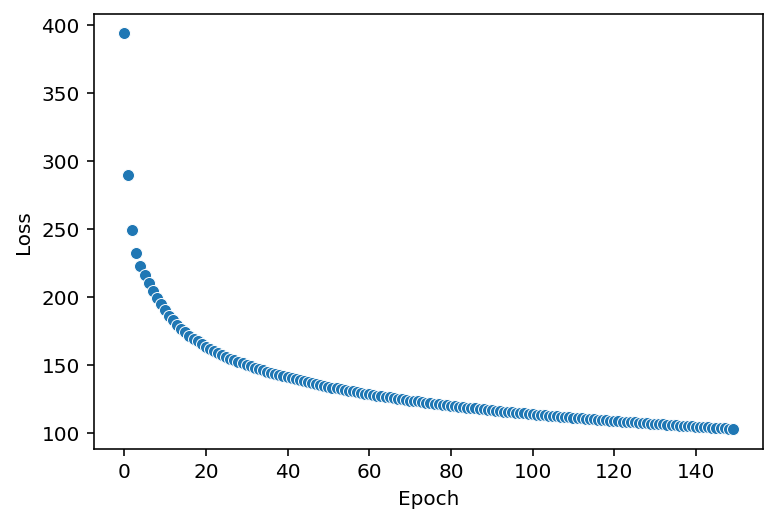

In [7]:
ax = sns.scatterplot(training_history.history['loss'])
ax.set_xlabel('Epoch')
_ = ax.set_ylabel('Loss')

# Sanity check: confirm that random sequences have lower likelihood than training seqs

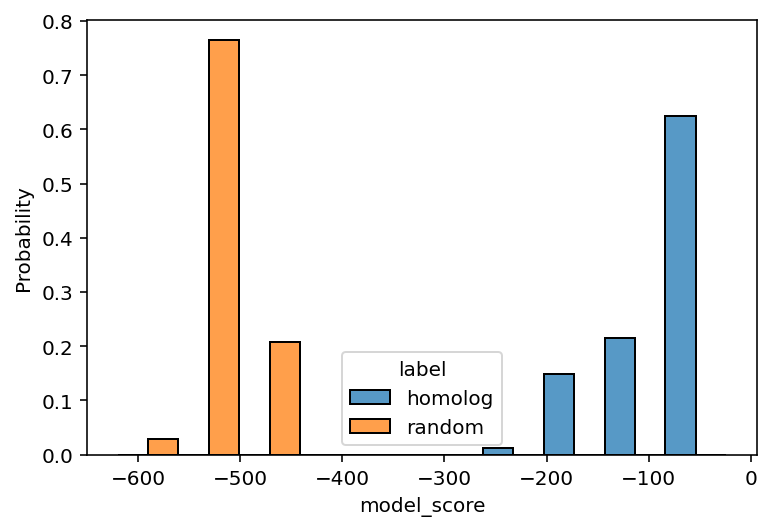

In [8]:
n = 250
homolog_seqs = [
    ''.join(tokens)
    for tokens in homolog_config.match_state_selector.select_from_aligned_seqs(
        msa.homologs
    )
]
homolog_seqs = homolog_seqs[:n]

random_seqs = homolog_config.match_state_domain.sample_uniformly(n)
random_seqs = homolog_config.match_state_domain.decode(random_seqs)

seq_df = pd.concat([
    pd.DataFrame(dict(sequence=homolog_seqs, label='homolog')),
    pd.DataFrame(dict(sequence=random_seqs, label='random')),
])
seq_df['model_score'] = msa_vae.get_likelihood_scores(
    seq_df['sequence'], vae_model, homolog_config
)

_ = sns.histplot(
    data=seq_df,
    x='model_score',
    hue='label',
    multiple='dodge',
    common_norm=False,
    stat='probability',
)